In [1]:
!pip install xlrd nbformat

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
FILE_PATH = r"C:\Users\ASUS\Desktop\Industrial practice\budget_execution_q1_2026.xlsx"
df_raw = pd.read_excel(FILE_PATH, engine='xlrd', header=None)
df_raw.iloc[0, 0] = 'Budget Execution Report — Alpha Construction LLP — Q1 2026'
print(f"Loaded! Shape: {df_raw.shape}")
df_raw.head(8)


Loaded! Shape: (115, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,Budget Execution Report — Alpha Construction L...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,тыс.тенге,NaN,NaN,NaN
2,ДОХОДЫ,Код стр.,Факт. 1 кв.2025,1 квартал 2026,NaN,NaN,NaN,%% к 1 кв . 2025,NaN,NaN,NaN
3,NaN,NaN,NaN,План,Факт,Отклонение,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,Сумма,%%,NaN,NaN,NaN,NaN
5,Наименование статьи,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Доходы от услуг техники,01,12516,10914,11792.39,878.39,1.080483,0.942185,NaN,NaN,NaN
7,Доходы от аренды АБЗ,02,0,0,76,76,0,0,NaN,NaN,NaN


In [4]:
income_rows = {
    'Equipment Services':          (6,  [2, 3, 4]),
    'Asphalt Plant Rental':        (7,  [2, 3, 4]),
    'Property Rental':             (8,  [2, 3, 4]),
    'Railway Siding':              (9,  [2, 3, 4]),
    'Olji Farm':                   (10, [2, 3, 4]),
    'Utility Cost Reimbursement':  (11, [2, 3, 4]),
    'Other Sales':                 (12, [2, 3, 4]),
}

income_data = []

for name, (row, cols) in income_rows.items():
    vals = df_raw.iloc[row, cols].values
    income_data.append({
        'Category': name,
        'Actual_2025': float(vals[0]) if str(vals[0]) not in ['nan', ''] else 0,
        'Plan_2026': float(vals[1]) if str(vals[1]) not in ['nan', ''] else 0,
        'Actual_2026': float(vals[2]) if str(vals[2]) not in ['nan', ''] else 0,
    })

df_income = pd.DataFrame(income_data)

df_income['Variance'] = df_income['Actual_2026'] - df_income['Plan_2026']
df_income['Performance_%'] = (
    df_income['Actual_2026'] /
    df_income['Plan_2026'].replace(0, np.nan) * 100
).round(1)
 
print("INCOME (thousand KZT)")
print(df_income)

INCOME (thousand KZT)
                     Category  Actual_2025  Plan_2026  Actual_2026  Variance  \
0          Equipment Services      12516.0    10914.0     11792.39    878.39   
1        Asphalt Plant Rental          0.0        0.0        76.00     76.00   
2             Property Rental      12742.0    14568.0     15904.00   1336.00   
3              Railway Siding        716.0        0.0       302.00    302.00   
4                   Olji Farm       2625.0     4292.0      1143.00  -3149.00   
5  Utility Cost Reimbursement       3664.0     3735.0      4703.00    968.00   
6                 Other Sales        497.0        0.0         0.00      0.00   

   Performance_%  
0          108.0  
1            NaN  
2          109.2  
3            NaN  
4           26.6  
5          125.9  
6            NaN  


In [5]:
expense_rows = {
    'Material Costs':             (21, [2, 3, 4]),
    'Fixed Asset Repairs':        (24, [2, 3, 4]),
    'Fuel and Energy':            (28, [2, 3, 4]),
    'Fuel and Lubricants':        (29, [2, 3, 4]),
    'Electricity':                (30, [2, 3, 4]),
    'Gas':                        (31, [2, 3, 4]),
    'Utility Expenses':           (32, [2, 3, 4]),
    'Third-Party Services':       (35, [2, 3, 4]),
    'Security':                   (40, [2, 3, 4]),
    'Labor Costs':                (42, [2, 3, 4]),
    'Payroll Fund':               (43, [2, 3, 4]),
    'Rent':                       (53, [2, 3, 4]),
}

expense_data = []

for name, (row, cols) in expense_rows.items():
    vals = df_raw.iloc[row, cols].values
    expense_data.append({
        'Category': name,
        'Actual_2025': float(str(vals[0]).replace(' ', '')) if str(vals[0]) not in ['nan', ''] else 0,
        'Plan_2026': float(str(vals[1]).replace(' ', '')) if str(vals[1]) not in ['nan', ''] else 0,
        'Actual_2026': float(str(vals[2]).replace(' ', '')) if str(vals[2]) not in ['nan', ''] else 0,
    })

df_expense = pd.DataFrame(expense_data)

df_expense['Variance'] = df_expense['Actual_2026'] - df_expense['Plan_2026']
df_expense['Performance_%'] = (
    df_expense['Actual_2026'] /
    df_expense['Plan_2026'].replace(0, np.nan) * 100
).round(1)

print("EXPENSES (thousand KZT) ===")
print(df_expense)

EXPENSES (thousand KZT) ===
                Category  Actual_2025  Plan_2026  Actual_2026  Variance  \
0         Material Costs       2995.0     1478.0        140.0   -1338.0   
1    Fixed Asset Repairs        988.0     1448.0        139.0   -1309.0   
2        Fuel and Energy       8914.0     8203.0       9825.0    1622.0   
3    Fuel and Lubricants       4961.0     4298.0       4809.0     511.0   
4            Electricity       3218.0     3251.0       3782.0     531.0   
5                    Gas        735.0      654.0       1234.0     580.0   
6       Utility Expenses         33.0       48.0        222.0     174.0   
7   Third-Party Services       4448.0     3141.0       2847.0    -294.0   
8               Security       2802.0     2099.0       2103.0       4.0   
9            Labor Costs      27595.0    31768.0      25884.0   -5884.0   
10          Payroll Fund      24276.0    28421.0      23353.0   -5068.0   
11                  Rent       3099.0     3071.0       3369.2     298.2 

In [6]:
total_income_plan = 33509
total_income_fact = 33920.39
total_expense_plan = 48451
total_expense_fact = 43306.2

net_plan = total_income_plan - total_expense_plan
net_fact = total_income_fact - total_expense_fact

summary = pd.DataFrame({
    'Metric': ['Income', 'Expenses', 'Net Income (Loss)'],
    'Plan (thousand KZT)': [total_income_plan, total_expense_plan, net_plan],
    'Actual (thousand KZT)': [total_income_fact, total_expense_fact, net_fact],
    'Variance': [
        total_income_fact - total_income_plan,
        total_expense_fact - total_expense_plan,
        net_fact - net_plan
    ],
})

print("SUMMARY")
print(summary.to_string(index=False))

print(f"\n Income exceeded the plan by:     +{total_income_fact - total_income_plan:,.1f} thousand KZT")
print(f" Expense savings:                  {total_expense_fact - total_expense_plan:,.1f} thousand KZT")
print(f" Net loss decreased by:           +{net_fact - net_plan:,.1f} thousand KZT vs. plan")

SUMMARY
           Metric  Plan (thousand KZT)  Actual (thousand KZT)  Variance
           Income                33509               33920.39    411.39
         Expenses                48451               43306.20  -5144.80
Net Income (Loss)               -14942               -9385.81   5556.19

 Income exceeded the plan by:     +411.4 thousand KZT
 Expense savings:                  -5,144.8 thousand KZT
 Net loss decreased by:           +5,556.2 thousand KZT vs. plan


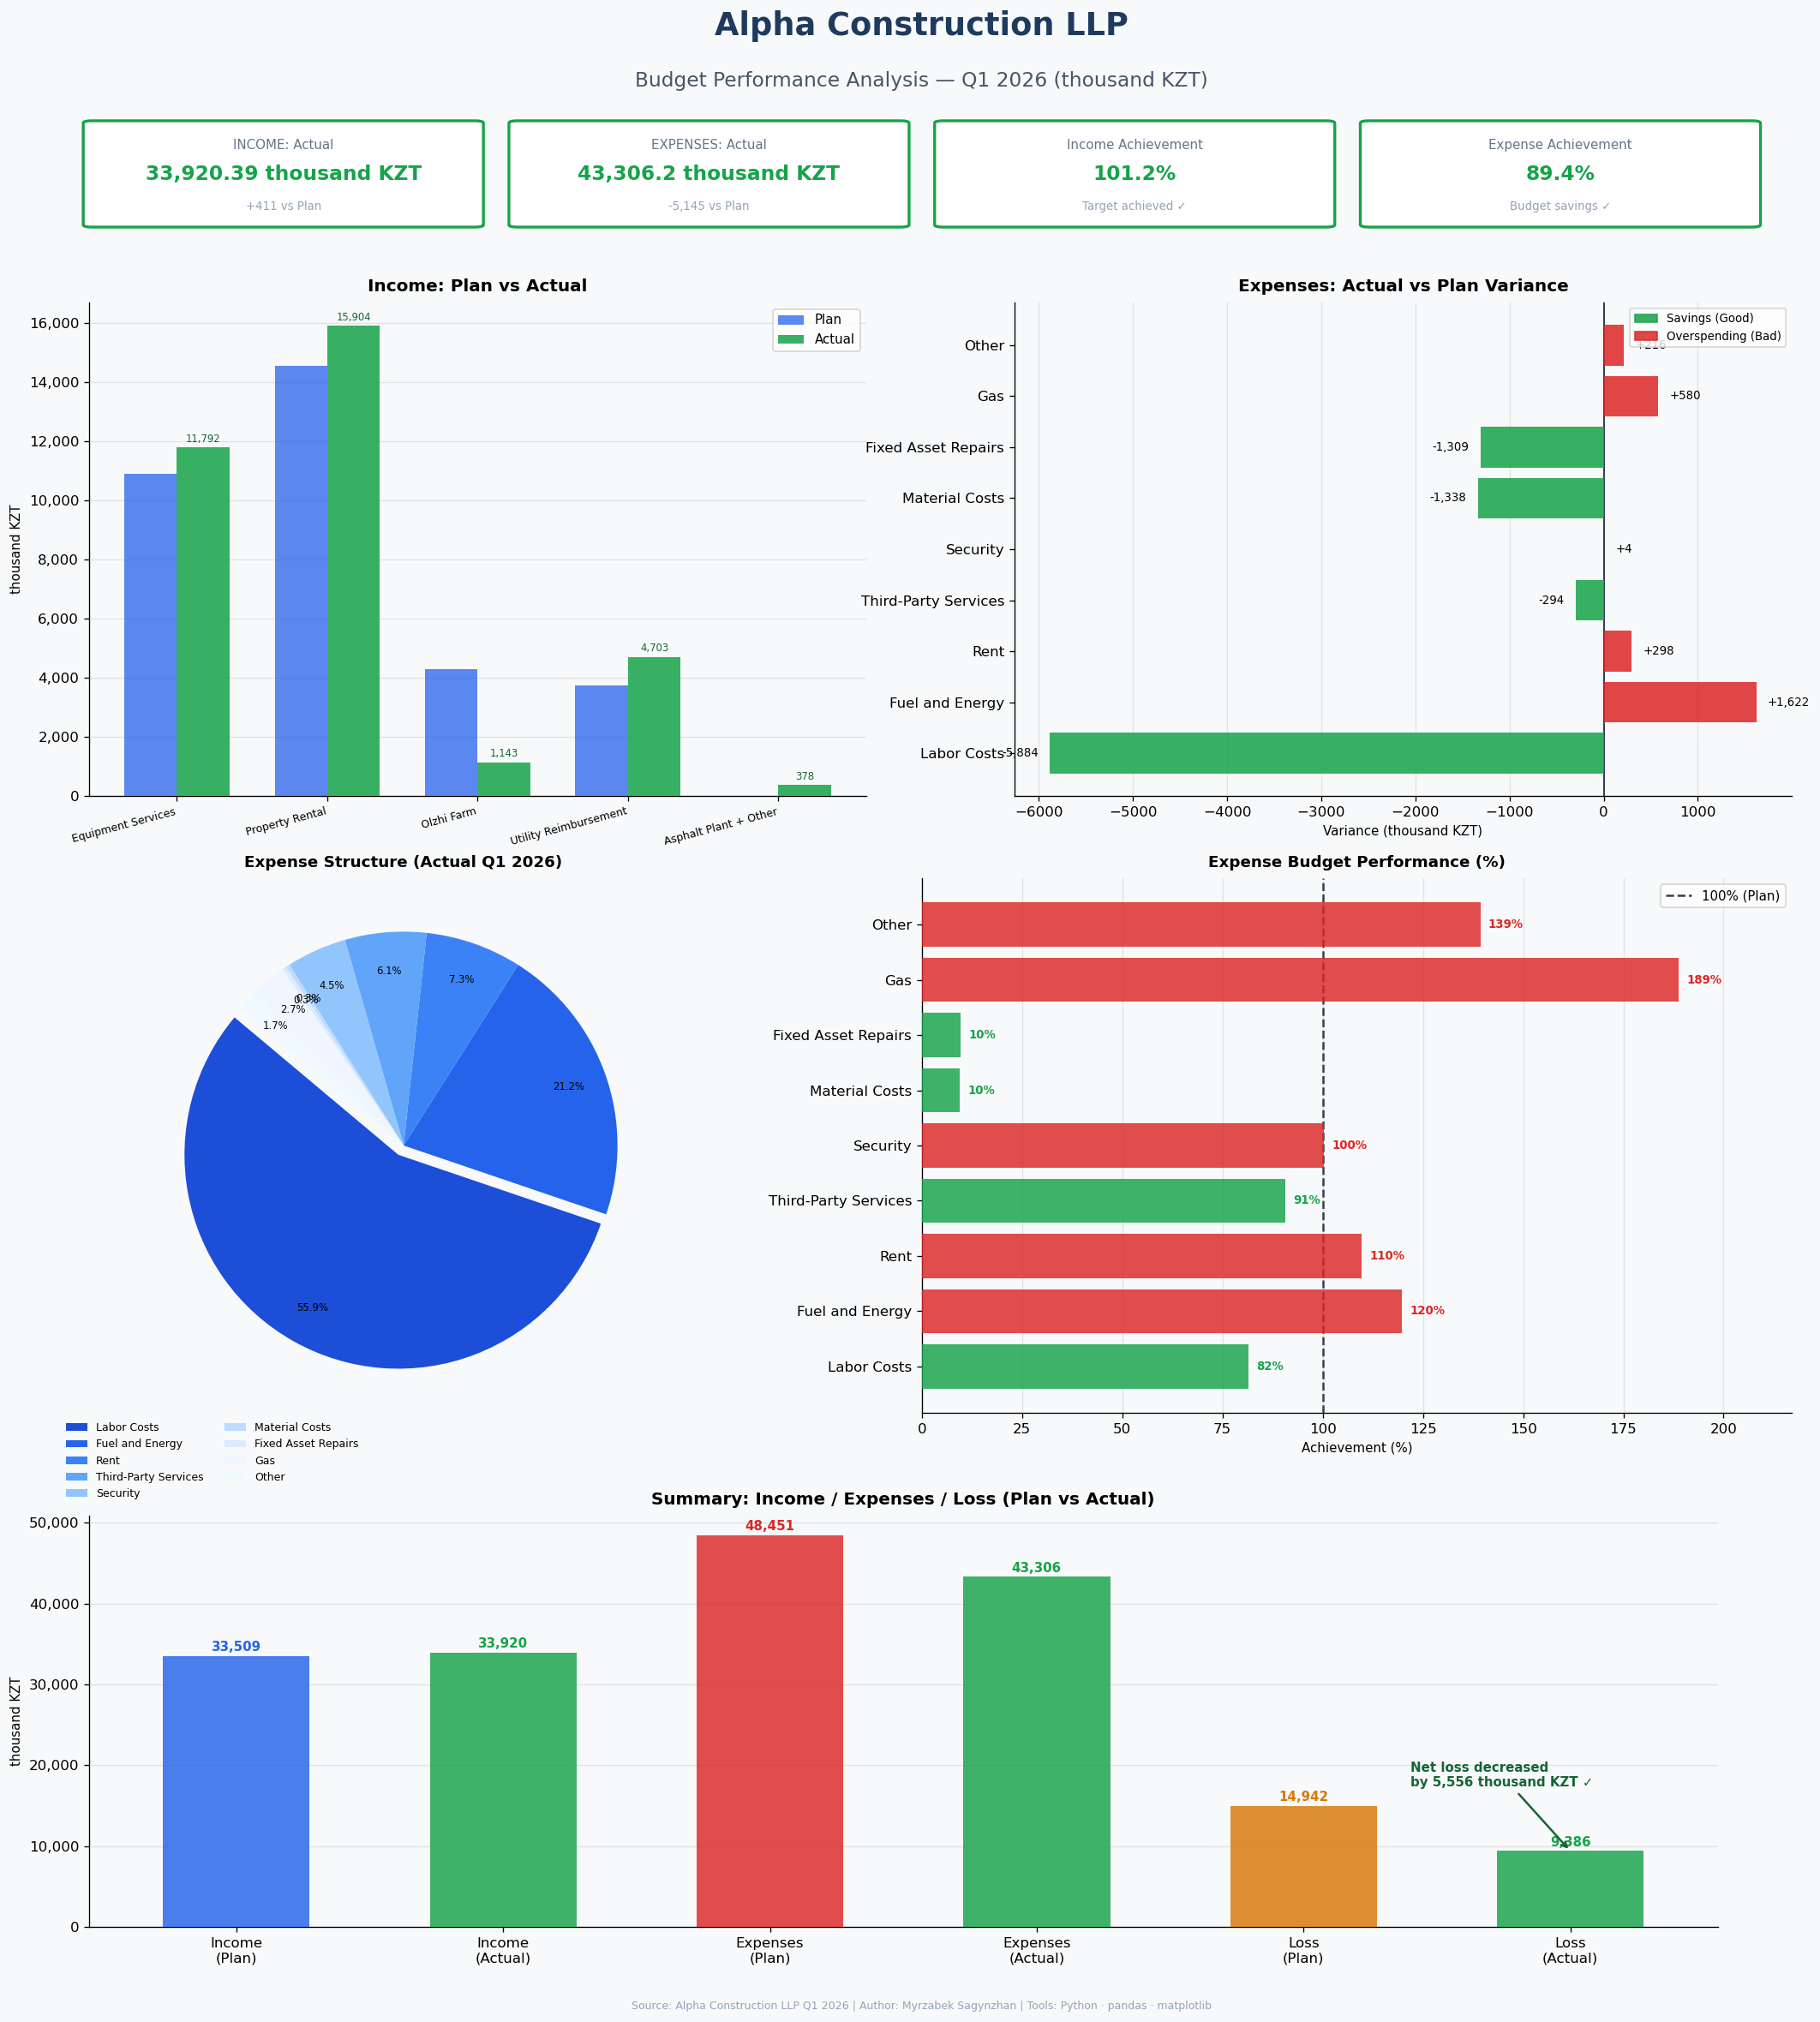

✅ Chart saved as budget_analysis_Q1_2026.png


In [7]:
BLUE  = '#2563EB'
GREEN = '#16A34A'
RED   = '#DC2626'
AMBER = '#D97706'

income_chart = pd.DataFrame([
    ('Equipment Services',       10914, 11792),
    ('Property Rental',          14568, 15904),
    ('Olzhi Farm',                 4292,  1143),
    ('Utility Reimbursement',     3735,  4703),
    ('Asphalt Plant + Other',        0,   378),
], columns=['Category', 'Plan', 'Actual'])

expense_chart = pd.DataFrame([
    ('Labor Costs',            31768, 25884),
    ('Fuel and Energy',         8203,  9825),
    ('Rent',                    3071,  3369),
    ('Third-Party Services',    3141,  2847),
    ('Security',                2099,  2103),
    ('Material Costs',          1478,   140),
    ('Fixed Asset Repairs',     1448,   139),
    ('Gas',                      654,  1234),
    ('Other',                    549,   765),
], columns=['Category', 'Plan', 'Actual'])

fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor('#F8F9FA')

fig.text(0.5, 0.97, 'Alpha Construction LLP', ha='center', fontsize=22, fontweight='bold', color='#1E3A5F')
fig.text(0.5, 0.945, 'Budget Performance Analysis — Q1 2026 (thousand KZT)', ha='center', fontsize=14, color='#475569')

kpi_ax = fig.add_axes([0.04, 0.875, 0.92, 0.055])
kpi_ax.set_xlim(0, 4)
kpi_ax.set_ylim(0, 1)
kpi_ax.axis('off')

kpis = [
    ('INCOME: Actual', f'{total_income_fact:,} thousand KZT', f'+{total_income_fact-total_income_plan:,.0f} vs Plan', GREEN),
    ('EXPENSES: Actual', f'{total_expense_fact:,} thousand KZT', f'{total_expense_fact-total_expense_plan:,.0f} vs Plan', GREEN),
    ('Income Achievement', f'{total_income_fact/total_income_plan*100:.1f}%', 'Target achieved ✓', GREEN),
    ('Expense Achievement', f'{total_expense_fact/total_expense_plan*100:.1f}%', 'Budget savings ✓', GREEN),
]

for i, (title, val, sub, col) in enumerate(kpis):
    x = i + 0.5
    kpi_ax.add_patch(
        mpatches.FancyBboxPatch(
            (i + 0.05, 0.05), 0.9, 0.9,
            boxstyle='round,pad=0.02',
            facecolor='white',
            edgecolor=col,
            lw=2
        )
    )
    kpi_ax.text(x, 0.72, title, ha='center', fontsize=9, color='#64748B')
    kpi_ax.text(x, 0.45, val, ha='center', fontsize=14, color=col, fontweight='bold')
    kpi_ax.text(x, 0.18, sub, ha='center', fontsize=8, color='#94A3B8')

ax1 = fig.add_axes([0.05, 0.60, 0.42, 0.24])
ax1.set_facecolor('#F8F9FA')

x = np.arange(len(income_chart))
w = 0.35

ax1.bar(x - w/2, income_chart['Plan'], w, color=BLUE, alpha=0.75, label='Plan', zorder=3)
bf = ax1.bar(x + w/2, income_chart['Actual'], w, color=GREEN, alpha=0.85, label='Actual', zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(income_chart['Category'], fontsize=7.5, rotation=15, ha='right')
ax1.set_ylabel('thousand KZT', fontsize=9)
ax1.set_title('Income: Plan vs Actual', fontsize=12, fontweight='bold', pad=8)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

for b in bf:
    ax1.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 100,
        f'{b.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=7,
        color='#166534'
    )

ax2 = fig.add_axes([0.55, 0.60, 0.42, 0.24])
ax2.set_facecolor('#F8F9FA')

devs = expense_chart['Actual'] - expense_chart['Plan']
col_dev = [GREEN if d < 0 else RED for d in devs]

bars2 = ax2.barh(expense_chart['Category'], devs, color=col_dev, alpha=0.85, zorder=3)
ax2.axvline(0, color='#334155', lw=1.2)
ax2.set_xlabel('Variance (thousand KZT)', fontsize=9)
ax2.set_title('Expenses: Actual vs Plan Variance', fontsize=12, fontweight='bold', pad=8)
ax2.grid(axis='x', alpha=0.3, zorder=0)

for b, d in zip(bars2, devs):
    ax2.text(
        d + (120 if d >= 0 else -120),
        b.get_y() + b.get_height()/2,
        f'{d:+,.0f}',
        va='center',
        ha='left' if d >= 0 else 'right',
        fontsize=8
    )

ax2.legend(handles=[
    mpatches.Patch(color=GREEN, alpha=0.85, label='Savings (Good)'),
    mpatches.Patch(color=RED, alpha=0.85, label='Overspending (Bad)')
], fontsize=8)

ax3 = fig.add_axes([0.03, 0.30, 0.38, 0.26])
ax3.set_facecolor('#F8F9FA')

pie_vals = expense_chart['Actual'].values
colors_pie = ['#1D4ED8','#2563EB','#3B82F6','#60A5FA','#93C5FD','#BFDBFE','#DBEAFE','#EFF6FF','#F0F9FF']
explode = [0.05 if v == max(pie_vals) else 0 for v in pie_vals]

wedges, _, autotexts = ax3.pie(
    pie_vals,
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=explode,
    startangle=140,
    pctdistance=0.82,
    textprops={'fontsize': 8}
)

for at in autotexts:
    at.set_fontsize(7)

ax3.legend(
    wedges,
    expense_chart['Category'],
    loc='lower left',
    bbox_to_anchor=(-0.15, -0.18),
    fontsize=7.5,
    ncol=2,
    frameon=False
)

ax3.set_title('Expense Structure (Actual Q1 2026)', fontsize=11, fontweight='bold', pad=8)

ax4 = fig.add_axes([0.50, 0.30, 0.47, 0.26])
ax4.set_facecolor('#F8F9FA')

pct = (expense_chart['Actual'] / expense_chart['Plan'] * 100).fillna(0).round(1)
col_pct = [GREEN if p <= 100 else RED for p in pct]

bh4 = ax4.barh(expense_chart['Category'], pct, color=col_pct, alpha=0.82, zorder=3)

ax4.axvline(100, color='#334155', lw=1.5, ls='--', label='100% (Plan)')
ax4.set_xlabel('Achievement (%)', fontsize=9)
ax4.set_xlim(0, max(pct) * 1.15)
ax4.set_title('Expense Budget Performance (%)', fontsize=11, fontweight='bold', pad=8)
ax4.grid(axis='x', alpha=0.3, zorder=0)

for b, p in zip(bh4, pct):
    ax4.text(
        p + 2,
        b.get_y() + b.get_height()/2,
        f'{p:.0f}%',
        va='center',
        ha='left',
        fontsize=8,
        fontweight='bold',
        color=GREEN if p <= 100 else RED
    )

ax4.legend(fontsize=9)

ax5 = fig.add_axes([0.05, 0.05, 0.88, 0.20])
ax5.set_facecolor('#F8F9FA')

cats = [
    'Income\n(Plan)',
    'Income\n(Actual)',
    'Expenses\n(Plan)',
    'Expenses\n(Actual)',
    'Loss\n(Plan)',
    'Loss\n(Actual)'
]

vals = [
    total_income_plan,
    total_income_fact,
    total_expense_plan,
    total_expense_fact,
    abs(net_plan),
    abs(net_fact)
]

col5 = [BLUE, GREEN, RED, GREEN, AMBER, GREEN]

bars5 = ax5.bar(cats, vals, color=col5, alpha=0.82, width=0.55, zorder=3)

ax5.set_ylabel('thousand KZT', fontsize=9)
ax5.set_title('Summary: Income / Expenses / Loss (Plan vs Actual)', fontsize=12, fontweight='bold', pad=8)
ax5.grid(axis='y', alpha=0.3, zorder=0)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

for b, v, c in zip(bars5, vals, col5):
    ax5.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 300,
        f'{v:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=c
    )

ax5.annotate(
    'Net loss decreased\nby 5,556 thousand KZT ✓',
    xy=(5, abs(net_fact)),
    xytext=(4.4, abs(net_fact) + 8000),
    fontsize=9,
    color='#166534',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#166534', lw=1.5)
)

fig.text(
    0.5,
    0.01,
    'Source: Alpha Construction LLP Q1 2026 | Author: Myrzabek Sagynzhan | Tools: Python · pandas · matplotlib',
    ha='center',
    fontsize=7.5,
    color='#94A3B8'
)

plt.savefig('budget_analysis_Q1_2026.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()

print("✅ Chart saved as budget_analysis_Q1_2026.png")